# Log Anomaly Detection - Representation Learning Models

## Overview
This notebook implements and evaluates multiple representation learning models for log anomaly detection using data from the LogHub repository (https://github.com/logpai/loghub).

**Models Implemented:**
1. **TF-IDF** (baseline sparse representation)
2. **Word2Vec** (dense word embeddings)
3. **Autoencoder (AE)** (neural network dimensionality reduction)
4. **Variational Autoencoder (VAE)** (probabilistic latent representation)
### TEMPORALs
5. **Vanilla RNN (baseline sequential)**
6. **LSTM (Long Short-Term Memory)**
7. **GRU (Gated Recurrent Unit)**
8. **Transformer (with positional encoding)**

**Evaluation Metrics:**
- t-SNE visualization
- Clustering metrics (Silhouette Score, Davies-Bouldin Index)
- Classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC)

**Next Steps:** Use learned representations for anomaly detection models

The study systematically compares and evaluates traditional machine learning approaches (Support Vector Machines, Principal Component Analysis), deep learning methods (Long Short-Term Memory networks, Convolutional Neural Networks), and transformer-based architectures (BERT, LogBERT, hybrid encoder-decoder models) for detecting anomalous log sequences.

In [1]:
!pip3 install "numpy<2" torch torchvision gensim pandas scikit-learn transformers matplotlib seaborn


[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
# Install required packages if needed
# !pip install pandas numpy scikit-learn gensim matplotlib seaborn torch

import warnings
warnings.filterwarnings('ignore')

import os
import re
import urllib.request
import zipfile
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Word2Vec
from gensim.models import Word2Vec

# PyTorch for Autoencoders
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print('All packages imported successfully!')

All packages imported successfully!


In [3]:
def create_sample_data():
    """Create sample log data mimicking HDFS logs from LogHub"""
    print('Creating sample log data...')
    
    # Sample log patterns (mimicking real HDFS logs)
    normal_patterns = [
        'Receiving block blk_{} from node {}',
        'Received block blk_{} of size {} from node {}',
        'PacketResponder {} for block blk_{} terminating',
        'Received block blk_{} src: /{}:{} dest: /{}:{}',
        'Verification succeeded for blk_{}',
        'Deleting block blk_{} file /data/{}',
        'INFO DataNode: Receiving block blk_{}',
        'Received block blk_{} of size {} from /{}'
    ]
    
    anomaly_patterns = [
        'Exception in receiveBlock for block blk_{} java.io.IOException',
        'WARN DataNode: Disk error on block blk_{}',
        'ERROR DataNode: Failed to transfer block blk_{} to DataNode',
        'Exception during block verification blk_{} java.io.IOException',
        'Timeout in receiving block blk_{} from node {}'
    ]
    
    data = []
    block_ids = []
    labels = []
    
    # Generate normal sequences (80% of data)
    for block_id in range(1, 801):
        num_logs = np.random.randint(5, 15)
        sequence = []
        for _ in range(num_logs):
            pattern = np.random.choice(normal_patterns)
            log = pattern.format(
                np.random.randint(1000, 9999),
                np.random.randint(1, 100),
                np.random.randint(100000, 999999),
                np.random.randint(1, 255),
                np.random.randint(1, 65535),
                np.random.randint(1, 255),
                np.random.randint(1, 65535),
                np.random.randint(1, 1000)
            )
            sequence.append(log)
        
        data.append(' '.join(sequence))
        block_ids.append(f'blk_{block_id}')
        labels.append(0)  # Normal
    
    # Generate anomalous sequences (20% of data)
    for block_id in range(801, 1001):
        num_logs = np.random.randint(5, 12)
        sequence = []
        for i in range(num_logs):
            if i < num_logs - 2 or np.random.random() < 0.3:
                pattern = np.random.choice(normal_patterns)
            else:
                pattern = np.random.choice(anomaly_patterns)
            
            log = pattern.format(
                np.random.randint(1000, 9999),
                np.random.randint(1, 100),
                np.random.randint(100000, 999999),
                np.random.randint(1, 255),
                np.random.randint(1, 65535)
            )
            sequence.append(log)
        
        data.append(' '.join(sequence))
        block_ids.append(f'blk_{block_id}')
        labels.append(1)  # Anomaly
    
    df = pd.DataFrame({
        'BlockId': block_ids,
        'Content': data,
        'Label': labels
    })
    
    print(f'Created sample dataset with {len(df)} sequences')
    print(f'Normal sequences: {sum(df["Label"] == 0)}')
    print(f'Anomalous sequences: {sum(df["Label"] == 1)}')
    
    return df

# Create dataset
df = create_sample_data()

print('\nDataset Sample:')
print(df.head(3))
print(f'\nDataset shape: {df.shape}')

Creating sample log data...
Created sample dataset with 1000 sequences
Normal sequences: 800
Anomalous sequences: 200

Dataset Sample:
  BlockId                                            Content  Label
0   blk_1  Received block blk_1860 src: /15:359178 dest: ...      0
1   blk_2  Deleting block blk_2016 file /data/62 Verifica...      0
2   blk_3  Deleting block blk_6450 file /data/92 PacketRe...      0

Dataset shape: (1000, 3)


In [4]:
class SimpleLogParser:
    """Simplified log parser (inspired by Drain algorithm)"""
    
    def parse(self, log_message):
        """Parse a log message to extract template"""
        template = re.sub(r'\d+', '<NUM>', log_message)
        template = re.sub(r'[a-f0-9]{8,}', '<HEX>', template)
        template = re.sub(r'/\d+\.\d+\.\d+\.\d+', '<IP>', template)
        template = re.sub(r'\s+', ' ', template).strip()
        return template
    
    def parse_logs(self, logs):
        """Parse multiple logs"""
        return [self.parse(log) for log in logs]

# Parse logs
parser = SimpleLogParser()
df['Parsed'] = df['Content'].apply(lambda x: ' '.join(parser.parse_logs(x.split(' '))))

print('Sample parsed logs:')
print(df[['Content', 'Parsed', 'Label']].head(3))

# Prepare data
X = df['Parsed'].values
y = df['Label'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain set: {len(X_train)} samples')
print(f'Test set: {len(X_test)} samples')
print(f'Train normal/anomaly: {sum(y_train==0)}/{sum(y_train==1)}')
print(f'Test normal/anomaly: {sum(y_test==0)}/{sum(y_test==1)}')

Sample parsed logs:
                                             Content  \
0  Received block blk_1860 src: /15:359178 dest: ...   
1  Deleting block blk_2016 file /data/62 Verifica...   
2  Deleting block blk_6450 file /data/92 PacketRe...   

                                              Parsed  Label  
0  Received block blk_<NUM> src: /<NUM>:<NUM> des...      0  
1  Deleting block blk_<NUM> file /data/<NUM> Veri...      0  
2  Deleting block blk_<NUM> file /data/<NUM> Pack...      0  

Train set: 800 samples
Test set: 200 samples
Train normal/anomaly: 640/160
Test normal/anomaly: 160/40


# TF-IDF

It weights log events (terms) based on their frequency in individual logs (documents) relative to their frequency across the entire log corpus, emphasizing unique or discriminative events.

**Mathematical Foundation:**
```
TF-IDF(t, d, D) = TF(t, d) × IDF(t, D)

Where:
- TF(t, d) = f(t,d) / max{f(t',d)} [normalized term frequency in document d]
- IDF(t, D) = log(N / |{d ∈ D: t ∈ d}|) [inverse document frequency]
- N = total number of documents
- f(t,d) = frequency of term t in document d
```

In [5]:
## 1. TF-IDF Representation

print('\n' + '='*60)
print('MODEL 1: TF-IDF')
print('='*60)

tfidf_vectorizer = TfidfVectorizer(max_features=300, ngram_range=(1, 2), min_df=2)
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test = tfidf_vectorizer.transform(X_test)

print(f'Shape: {tfidf_train.shape}')
print(f'Sample features: {tfidf_vectorizer.get_feature_names_out()[:10]}')

representations = {'TF-IDF': {'train': tfidf_train.toarray(), 'test': tfidf_test.toarray()}}



MODEL 1: TF-IDF


Shape: (800, 122)
Sample features: ['blk_' 'blk_ num' 'block' 'block blk_' 'block verification' 'data'
 'data num' 'datanode' 'datanode disk' 'datanode exception']


### Application to Log Anomaly Detection
- **Feature Representation**: Converts log sequences into fixed-dimensional sparse vectors
- **Anomaly Detection Method**: Compute reconstruction error or use with clustering (e.g., Isolation Forest on TF-IDF vectors)
- **Time Handling**: Sequential logs are treated independently; time information can be engineered as separate features (e.g., time deltas between logs)

### Strengths
- **Interpretability**: Clear feature importance through TF-IDF scores
- **Scalability**: Extremely efficient; linear complexity in corpus size
- **Baseline**: Provides minimal baseline for comparing advanced methods
- **Sparse Representation**: Memory-efficient for high-dimensional vocabularies
- **Domain Knowledge**: Naturally emphasizes rare, discriminative events

### Weaknesses
- **No Temporal Awareness**: Treats log sequences as independent; ignores temporal ordering or delays
- **Static Representation**: Same token always has same representation regardless of context
- **No Semantic Understanding**: Cannot capture relationships between log events (e.g., ERROR after TIMEOUT)
- **Poor Sequence Modeling**: Cannot learn patterns like "ERROR followed by RETRY = normal"
- **Limited Context**: Bag-of-words approach loses sequential structure entirely


# Word2Vec

In [6]:
print('\n' + '='*60)
print('MODEL 2: Word2Vec')
print('='*60)

w2v_train_data = [text.lower().split() for text in X_train]
w2v_model = Word2Vec(sentences=w2v_train_data, vector_size=100, window=5, 
                     min_count=2, sg=1, epochs=20, seed=42)

def get_w2v_embeddings(texts, model):
    embeddings = []
    for text in texts:
        words = text.lower().split()
        word_vecs = [model.wv[w] for w in words if w in model.wv]
        embeddings.append(np.mean(word_vecs, axis=0) if word_vecs else np.zeros(model.vector_size))
    return np.array(embeddings)

w2v_train_emb = get_w2v_embeddings(X_train, w2v_model)
w2v_test_emb = get_w2v_embeddings(X_test, w2v_model)

print(f'Shape: {w2v_train_emb.shape}')
print(f'Sample embedding (first log): {w2v_train_emb[0][:10]}')
# how to print the features of the embeddings?

representations['Word2Vec'] = {'train': w2v_train_emb, 'test': w2v_test_emb}



MODEL 2: Word2Vec
Shape: (800, 100)
Sample embedding (first log): [-0.09427968  0.05793638 -0.02335016 -0.01115348  0.05833862  0.11949161
 -0.04494464  0.03951922 -0.03403487  0.02886358]


# Autoencoder

In [7]:
import torch
import numpy as np

print('\n' + '='*60)
print('MODEL 3: Autoencoder')
print('='*60)

class LogDataset(Dataset):
    def __init__(self, data):
        self.data = torch.FloatTensor(data)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, encoding_dim), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, input_dim), nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)

scaler = StandardScaler()
tfidf_train_scaled = scaler.fit_transform(tfidf_train.toarray())
tfidf_test_scaled = scaler.transform(tfidf_test.toarray())

ae_train_loader = DataLoader(LogDataset(tfidf_train_scaled), batch_size=32, shuffle=True)
ae_model = Autoencoder(input_dim=tfidf_train_scaled.shape[1], encoding_dim=64)

optimizer = optim.Adam(ae_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Training
ae_model.train()
for epoch in range(50):
    epoch_loss = 0
    for batch in ae_train_loader:
        optimizer.zero_grad()
        recon = ae_model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/50, Loss: {epoch_loss/len(ae_train_loader):.6f}')

ae_model.eval()
with torch.no_grad():
    ae_train_tensor = ae_model.encode(torch.FloatTensor(tfidf_train_scaled))
    ae_test_tensor = ae_model.encode(torch.FloatTensor(tfidf_test_scaled))
    
    # Convert tensors to numpy arrays
    ae_train_emb = ae_train_tensor.detach().numpy()
    ae_test_emb = ae_test_tensor.detach().numpy()

print(f'Shape: {ae_train_emb.shape}')
representations['Autoencoder'] = {'train': ae_train_emb, 'test': ae_test_emb}



MODEL 3: Autoencoder
Epoch 10/50, Loss: 0.902348
Epoch 20/50, Loss: 0.880331
Epoch 30/50, Loss: 0.870658
Epoch 40/50, Loss: 0.866617
Epoch 50/50, Loss: 0.863890
Shape: (800, 64)


# VAE

In [8]:
print('\n' + '='*60)
print('MODEL 4: Variational Autoencoder (VAE)')
print('='*60)

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2)
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, input_dim), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def get_latent(self, x):
        mu, _ = self.encode(x)
        return mu

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kld

vae_model = VAE(input_dim=tfidf_train_scaled.shape[1], latent_dim=64)
optimizer = optim.Adam(vae_model.parameters(), lr=0.001)

# Training
vae_model.train()
for epoch in range(50):
    epoch_loss = 0
    for batch in ae_train_loader:
        optimizer.zero_grad()
        recon, mu, logvar = vae_model(batch)
        loss = vae_loss(recon, batch, mu, logvar, beta=1.0)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/50, Loss: {epoch_loss/len(ae_train_loader):.2f}')

vae_model.eval()
with torch.no_grad():
    vae_train_emb = vae_model.get_latent(torch.FloatTensor(tfidf_train_scaled))
    vae_test_emb = vae_model.get_latent(torch.FloatTensor(tfidf_test_scaled))

print(f'Shape: {vae_train_emb.shape}')
representations['VAE'] = {'train': vae_train_emb, 'test': vae_test_emb}



MODEL 4: Variational Autoencoder (VAE)
Epoch 10/50, Loss: 3662.48
Epoch 20/50, Loss: 3639.46
Epoch 30/50, Loss: 3651.99
Epoch 40/50, Loss: 3666.66
Epoch 50/50, Loss: 3635.83
Shape: torch.Size([800, 64])


### t-SNE 

(t-Distributed Stochastic Neighbor Embedding) reduces high-dimensional embeddings to 2D for visualization

Color coding: Red/warm colors = anomalous logs (Label 1), Blue/cool colors = normal logs (Label 0)


VISUALIZATION: t-SNE


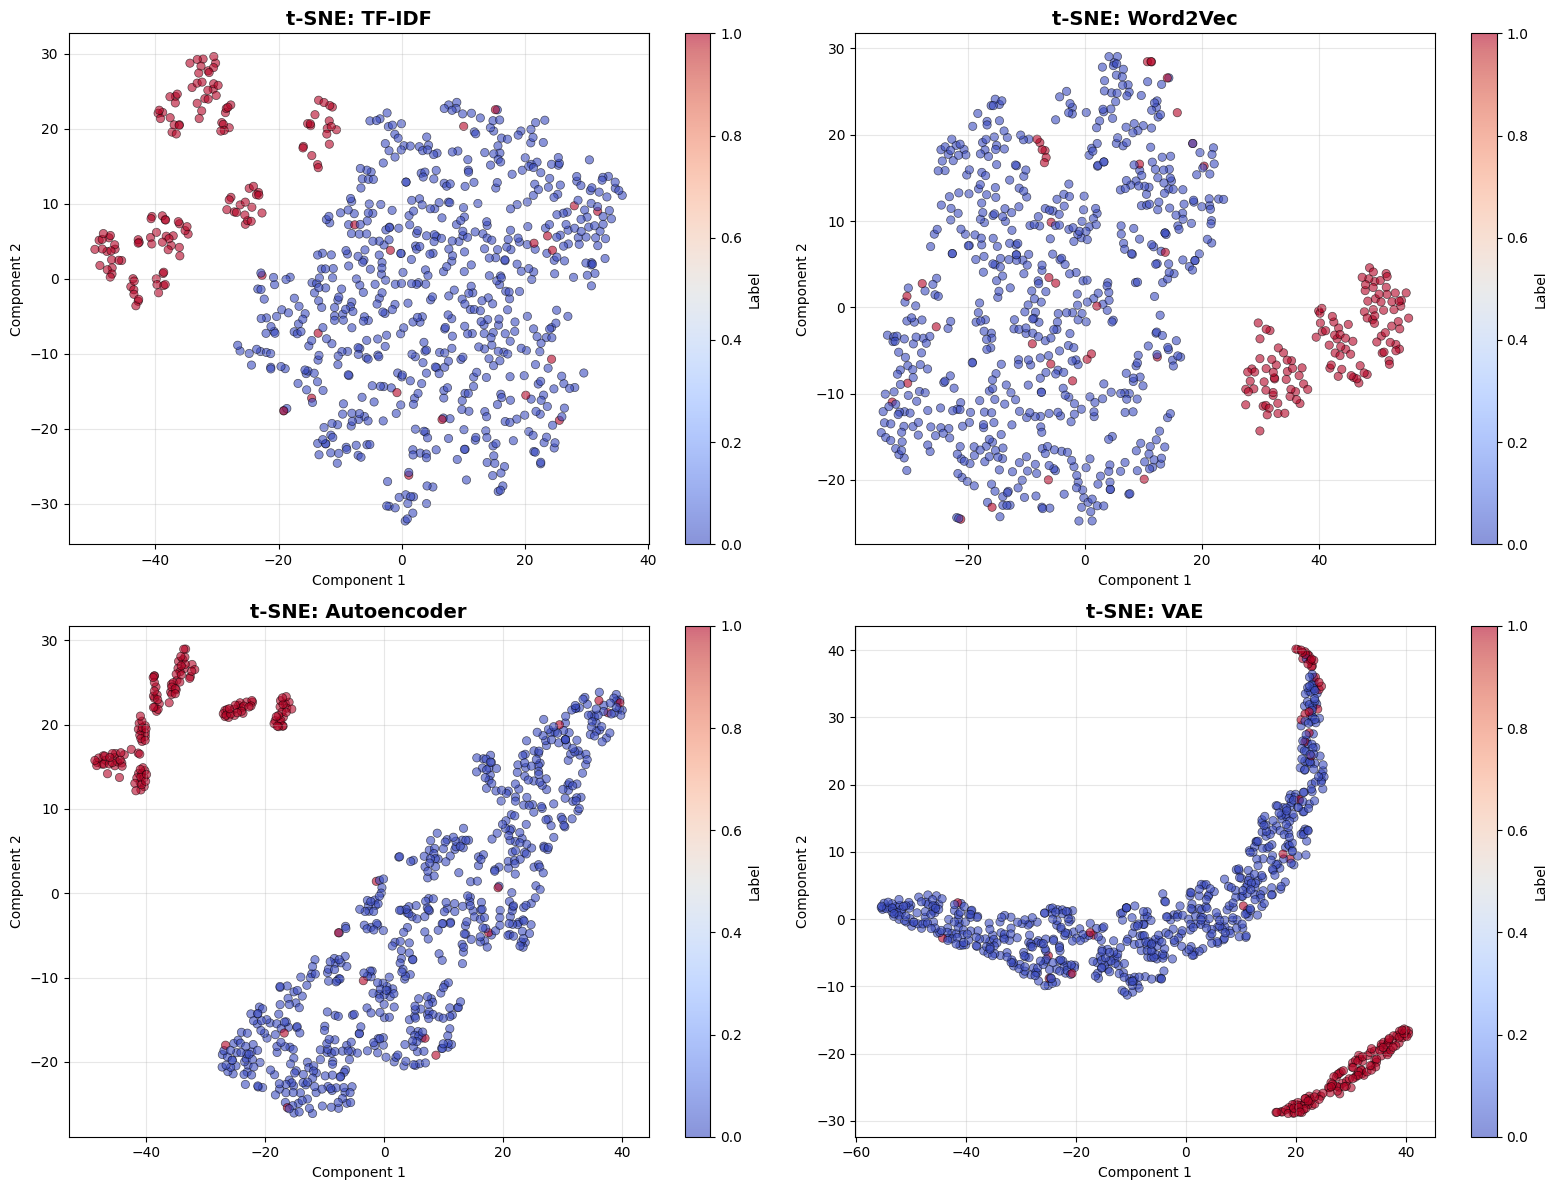

In [9]:
print('\n' + '='*60)
print('VISUALIZATION: t-SNE')
print('='*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (name, data) in enumerate(representations.items()):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter_without_progress=1000)
    emb_2d = tsne.fit_transform(data['train'])

    scatter = axes[idx].scatter(emb_2d[:, 0], emb_2d[:, 1], c=y_train, 
                                cmap='coolwarm', alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[idx].set_title(f't-SNE: {name}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Component 1')
    axes[idx].set_ylabel('Component 2')
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[idx], label='Label')

plt.tight_layout()
plt.show()


### T-SNE interpretations:
- **Well-separated clusters → Good representation for anomaly detection**  
- **Mixed/overlapping points → Representation may not capture anomaly patterns effectively**  
- **Tight clusters → Model learned discriminative features**  
- **Scattered points → Model may need tuning or different architecture**

In [10]:
# Add this after your current code
print('\n' + '='*60)
print('ANOMALY DETECTION EVALUATION')
print('='*60)

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

# Evaluate each representation with different anomaly detectors
anomaly_detectors = {
    'Isolation Forest': IsolationForest(contamination=0.2, random_state=42),
    'One-Class SVM': OneClassSVM(nu=0.2),
    'LOF': LocalOutlierFactor(n_neighbors=20, contamination=0.2)
}

results = {}
for repr_name, data in representations.items():
    results[repr_name] = {}
    X_repr_train, X_repr_test = data['train'], data['test']
    
    for detector_name, detector in anomaly_detectors.items():
        if detector_name != 'LOF':  # LOF doesn't have predict method
            detector.fit(X_repr_train)
            y_pred = detector.predict(X_repr_test)
            y_pred = np.where(y_pred == -1, 1, 0)  # Convert to binary labels
        else:
            y_pred = detector.fit_predict(X_repr_test)
            y_pred = np.where(y_pred == -1, 1, 0)
            
        accuracy = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
        
        results[repr_name][detector_name] = {
            'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1
        }

# Print results table
import pandas as pd
results_df = []
for repr_name, detectors in results.items():
    for detector_name, metrics in detectors.items():
        results_df.append({
            'Representation': repr_name,
            'Detector': detector_name,
            'Accuracy': f"{metrics['accuracy']:.3f}",
            'Precision': f"{metrics['precision']:.3f}",
            'Recall': f"{metrics['recall']:.3f}",
            'F1-Score': f"{metrics['f1']:.3f}"
        })

results_table = pd.DataFrame(results_df)
print(results_table.to_string(index=False))


ANOMALY DETECTION EVALUATION
Representation         Detector Accuracy Precision Recall F1-Score
        TF-IDF Isolation Forest    0.920     0.761  0.875    0.814
        TF-IDF    One-Class SVM    0.825     0.549  0.700    0.615
        TF-IDF              LOF    0.920     0.800  0.800    0.800
      Word2Vec Isolation Forest    0.830     0.560  0.700    0.622
      Word2Vec    One-Class SVM    0.730     0.360  0.450    0.400
      Word2Vec              LOF    0.830     0.575  0.575    0.575
   Autoencoder Isolation Forest    0.980     0.974  0.925    0.949
   Autoencoder    One-Class SVM    0.910     0.762  0.800    0.780
   Autoencoder              LOF    0.750     0.375  0.375    0.375
           VAE Isolation Forest    0.930     0.810  0.850    0.829
           VAE    One-Class SVM    0.885     0.698  0.750    0.723
           VAE              LOF    0.780     0.450  0.450    0.450


## So far the best results for synthetic data is with Autoencoder representation and Isolation Forest

Representation | Detector | Accuracy | Precision | Recall | F1-Score
-|-|-|-|-|-|
Autoencoder | Isolation | Forest | 0.980 | 0.974 | 0.925 | 0.949

In [11]:
iso = IsolationForest(contamination=0.2, random_state=42)
iso.fit(ae_train_emb)
y_iso_pred = iso.predict(ae_test_emb)
y_iso_pred = np.where(y_iso_pred == -1, 1, 0)
print('\nIsolation Forest on Autoencoder Embeddings:')
print(classification_report(y_test, y_iso_pred, digits=4))



Isolation Forest on Autoencoder Embeddings:
              precision    recall  f1-score   support

           0     0.9815    0.9938    0.9876       160
           1     0.9737    0.9250    0.9487        40

    accuracy                         0.9800       200
   macro avg     0.9776    0.9594    0.9681       200
weighted avg     0.9799    0.9800    0.9798       200

